# Exp09b.1 — M15 Structural Invariance Test (Out-of-Time)

### Why this experiment exists

Exp09b returned **INCONCLUSIVE** (3/4 criteria, n=12). E_net > 0 point estimate, LOO stable, FQR=0.945.
The only failure: CI too wide due to insufficient sample size.

**This is NOT a new experiment.** It is a statistical power extension with a critical constraint:
> **Zero threshold changes. Zero parameter re-optimization. Zero new hypothesis searching.**
> The only change is: more data, applied to a frozen hypothesis.

### Methodology: Out-of-Time Transfer Test

Thresholds calibrated in 09a on 2025-05-29 → 2026-03-28.
Applied here to 2022-01-01 → 2025-05-28 — data that **never existed** when 09a was designed.

This creates something genuinely rare in retail research:
- Not cross-validation (same dataset, different fold)
- Not walk-forward (parameter allowed to shift)
- **True out-of-time transfer**: thresholds from 2025 applied to 2022 market conditions

If the mechanism survives 2022 bear → 2023 transition → 2024 bull → 2025 current,
it is unlikely to be a regime-specific statistical accident.

### Hypothesis Under Test

> In M15 EER=Low+Vol=Low bursts, inventory transfer dynamics create:
> 1. Initial pullback (fills maker limit)
> 2. Absorption / stabilization
> 3. Delayed continuation in burst direction
> 4. Anti-adverse selection at fill point (FQR > 1.0)
>
> This pattern should be **geometrically similar** across regimes if it is structural.

### Decision Criteria (upgraded from 09b)

With n≈60-80, the decisive criteria shift from point estimate to:

| Criterion | Threshold | Why |
|-----------|-----------|-----|
| E_net > 0 | point est | Direction check |
| **CI_lower > 0** | all blocks | Statistical bound (primary) |
| **LOO stability** | P > 0.70 | Anti-winner's-curse |
| **Shape correlation** | r > 0.70 vs 09a train | Geometric invariance |
| **Regime sign consistency** | ≥ 3/4 regimes positive | Structural (not regime-specific) |

If all 5 pass → **"Candidate Structural Effect"** (first truly serious result of the research).

### Regimes

| Label | Period | BTC context |
|-------|--------|-------------|
| 2022-bear | 2022-01-01 → 2022-12-31 | 47k → 16k (-65%) |
| 2023-transition | 2023-01-01 → 2023-12-31 | 16k → 43k (+170%) |
| 2024-bull | 2024-01-01 → 2024-12-31 | 43k → 97k (+126%), ETF Jan |
| 2025-current | 2025-01-01 → 2025-05-28 | 97k → ~109k (pre-09a train) |


In [1]:
import hashlib, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M1.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEP = '=' * 68

# ── ALL THRESHOLDS FROZEN FROM Exp09a (SPEC_HASH 89f1a4e54b3a) ──────────────
# DO NOT CHANGE. DO NOT RECALIBRATE. INVARIANCE TEST ONLY.
ATR_THRESH_M15        = 1.7027   # P90 of M15 TR/ATR on 09a train (2025-05-29 to 2026-03-28)
EER_LOW_M15           = 0.4167   # P40 of M15 EER on 09a train
VOL_LOW_PCT_M15       = 0.50
ATR_WINDOW_M15        = 20
PERCENTILE_WINDOW_M15 = 500
FILL_EPSILON          = 0.0001
PRIMARY_H             = 5        # h=5 (75 min) — frozen from 09a analysis
PATH_H                = 10       # for path shape analysis
FILL_HORIZONS         = [1, 3]
BLOCK_SIZES           = [3, 5, 10]
N_BOOTSTRAP           = 2000
LOO_STABLE_THRESH     = 0.70
SHAPE_CORR_THRESH     = 0.70
REGIME_SIGN_THRESH    = 3        # min regimes with E_net > 0 (out of 4)

# ── DATA SPLITS ──────────────────────────────────────────────────────────────
HIST_OOS_START  = pd.Timestamp('2022-01-01', tz='UTC')   # historical out-of-time start
TRAIN_09A_START = pd.Timestamp('2025-05-29', tz='UTC')   # 09a calibration start
TRAIN_09A_END   = pd.Timestamp('2026-03-29', tz='UTC')   # 09b holdout start
HOLDOUT_09B_END = pd.Timestamp('2026-05-25', tz='UTC')   # approximate end of 09b data

# Regime definitions for segmentation analysis
REGIMES = {
    '2022-bear':       (pd.Timestamp('2022-01-01', tz='UTC'), pd.Timestamp('2023-01-01', tz='UTC')),
    '2023-transition': (pd.Timestamp('2023-01-01', tz='UTC'), pd.Timestamp('2024-01-01', tz='UTC')),
    '2024-bull':       (pd.Timestamp('2024-01-01', tz='UTC'), pd.Timestamp('2025-01-01', tz='UTC')),
    '2025-current':    (pd.Timestamp('2025-01-01', tz='UTC'), TRAIN_09A_START),
}

# ── COST MODEL ───────────────────────────────────────────────────────────────
MAKER_REBATE = 0.0002
TAKER_FEE    = 0.0004
NET_COST_MT  = TAKER_FEE - MAKER_REBATE
NET_COST_MM  = -(2 * MAKER_REBATE)

# ── REFERENCES FROM 09a/09b ──────────────────────────────────────────────────
REF_09A = {
    'spec_hash'   : '89f1a4e54b3a',
    'n_train'     : 61,
    'fqr_C3c'     : 1.223,
    'pcont_h1'    : 42.6,
    'pcont_h5'    : 56.1,
    'drift_3c_pct': -0.05847,
}
REF_09B = {
    'spec_hash': 'c40753cfb893',
    'n_holdout': 12,
    'fqr_C3c'  : 0.945,
    'enet_pos' : True,
    'loo_pass' : True,
    'ci_fail'  : True,   # CI crossed zero (expected with n=12)
}

SPEC = {
    'version'       : '09b1-v1',
    'prior_09a'     : REF_09A['spec_hash'],
    'prior_09b'     : REF_09B['spec_hash'],
    'objective'     : 'structural_invariance_out_of_time',
    'hist_oos_start': str(HIST_OOS_START.date()),
    'atr_thresh'    : ATR_THRESH_M15,
    'eer_low'       : EER_LOW_M15,
    'primary_h'     : PRIMARY_H,
}
SPEC_HASH = hashlib.sha256(json.dumps(SPEC, sort_keys=True).encode()).hexdigest()[:12]

print('Cell 2 OK — Exp09b.1: M15 Structural Invariance Test')
print(f'SPEC_HASH: {SPEC_HASH}')
print(f'Historical OOS: {HIST_OOS_START.date()} -> {TRAIN_09A_START.date()}')
print(f'Frozen thresholds: ATR={ATR_THRESH_M15}  EER_LOW={EER_LOW_M15}  (09a, 2025-2026 train)')
print(f'Block sizes: {BLOCK_SIZES}  |  Primary h={PRIMARY_H}  |  n_boot={N_BOOTSTRAP}')
print(f'GO criteria: CI_lower>0 AND LOO_stable>={LOO_STABLE_THRESH} AND shape_r>={SHAPE_CORR_THRESH} AND {REGIME_SIGN_THRESH}+/4 regimes')


Cell 2 OK — Exp09b.1: M15 Structural Invariance Test
SPEC_HASH: 15610181a8cd
Historical OOS: 2022-01-01 -> 2025-05-29
Frozen thresholds: ATR=1.7027  EER_LOW=0.4167  (09a, 2025-2026 train)
Block sizes: [3, 5, 10]  |  Primary h=5  |  n_boot=2000
GO criteria: CI_lower>0 AND LOO_stable>=0.7 AND shape_r>=0.7 AND 3+/4 regimes


In [2]:
# Load M1 (2022-2026) + resample M15 + features on full series
df_m1 = pd.read_csv(DATA_FILE)
df_m1['open_time'] = pd.to_datetime(df_m1['open_time'], unit='ms', utc=True)
df_m1 = df_m1.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_m1[col] = df_m1[col].astype(float)

print(f'M1 loaded: {len(df_m1):,} candles | {df_m1["open_time"].iloc[0].date()} -> {df_m1["open_time"].iloc[-1].date()}')

if df_m1['open_time'].iloc[0].year > 2022:
    print('WARN: Data does not start in 2022. Run:')
    print('  python scripts/download_data.py --symbol BTCUSDT --interval 1m --start-date 2022-01-01')

# Resample M1 -> M15
df_full = (df_m1.set_index('open_time')
           .resample('15min')
           .agg({'open':'first','high':'max','low':'min','close':'last','volume':'sum'})
           .dropna(subset=['open','close'])
           .reset_index())
df_full['date'] = df_full['open_time'].dt.date

print(f'M15 full: {len(df_full):,} candles  |  expected {int((df_m1["open_time"].iloc[-1]-df_m1["open_time"].iloc[0]).days * 96 * 0.98 / 100) * 100:,}+')

# ATR + EER + vol_pct (full series — rolling integrity)
prev_close          = df_full['close'].shift(1)
df_full['tr']       = np.maximum(df_full['high'] - df_full['low'],
                      np.maximum((df_full['high'] - prev_close).abs(),
                                 (df_full['low']  - prev_close).abs()))
df_full['atr']      = df_full['tr'].rolling(ATR_WINDOW_M15, min_periods=ATR_WINDOW_M15//2).mean()
df_full['tr_ratio'] = df_full['tr'] / df_full['atr']
body                = (df_full['close'] - df_full['open']).abs()
rng                 = (df_full['high'] - df_full['low']).replace(0, np.nan)
df_full['eer']      = (body / rng).clip(0, 1)
df_full['dir_sign'] = np.where(df_full['close'] >= df_full['open'], 1.0, -1.0)
df_full['vol_pct']  = df_full['volume'].rolling(PERCENTILE_WINDOW_M15, min_periods=50).rank(pct=True)

# Forward closes (PATH_H candles, by date)
for h in range(1, PATH_H + 1):
    df_full[f'fwd_c{h}'] = df_full.groupby('date')['close'].shift(-h)

# Fill detection features
for h in FILL_HORIZONS:
    df_full[f'fwd_min_low_{h}']   = df_full['low'].rolling(h).min().shift(-h)
    df_full[f'fwd_max_high_{h}']  = df_full['high'].rolling(h).max().shift(-h)
    df_full[f'fwd_close_min_{h}'] = df_full['close'].rolling(h).min().shift(-h)
    df_full[f'fwd_close_max_{h}'] = df_full['close'].rolling(h).max().shift(-h)

# Cont returns h=1..PATH_H
for h in range(1, PATH_H + 1):
    df_full[f'cont_{h}c'] = (df_full[f'fwd_c{h}'] - df_full['close']) * df_full['dir_sign'] / df_full['close']

# Annotate regime
def get_regime(ts):
    for rname, (rs, re) in REGIMES.items():
        if rs <= ts < re:
            return rname
    return 'other'

df_full['regime'] = df_full['open_time'].apply(get_regime)

# Partition
df_hist    = df_full[(df_full['open_time'] >= HIST_OOS_START) &
                     (df_full['open_time'] <  TRAIN_09A_START)].copy()
df_train09a= df_full[(df_full['open_time'] >= TRAIN_09A_START) &
                     (df_full['open_time'] <  TRAIN_09A_END)].copy()
df_holdout09b = df_full[df_full['open_time'] >= TRAIN_09A_END].copy()

print(f'\nPartitions:')
print(f'  Historical OOS (09b.1):   {len(df_hist):,} M15  |  {df_hist["open_time"].iloc[0].date()} -> {df_hist["open_time"].iloc[-1].date()}')
print(f'  09a Train (reference):    {len(df_train09a):,} M15  |  calibration — NOT re-analyzed as new OOS data')
print(f'  09b Holdout (reference):  {len(df_holdout09b):,} M15  |  n=12 from 09b (shown for completeness)')
print('Cell 3 OK')


M1 loaded: 2,313,701 candles | 2022-01-01 -> 2026-05-26
M15 full: 154,248 candles  |  expected 151,000+

Partitions:
  Historical OOS (09b.1):   119,419 M15  |  2022-01-01 -> 2025-05-28
  09a Train (reference):    29,184 M15  |  calibration — NOT re-analyzed as new OOS data
  09b Holdout (reference):  5,645 M15  |  n=12 from 09b (shown for completeness)
Cell 3 OK


In [3]:
# Distribution stability: frozen thresholds across regimes
print(SEP)
print('CELL 4 - THRESHOLD STABILITY ACROSS REGIMES')
print(f'FROZEN: ATR_THRESH={ATR_THRESH_M15}  EER_LOW={EER_LOW_M15}')
print('Checking distributional stability — NOT recalibrating.')
print('Goal: understand how "P90 of M15 TR/ATR" maps to each regime.')
print(SEP)

print(f'\n  {"Period":<20}  {"P(ATR>thresh)":>14}  {"P90_ATR":>10}  {"P(EER<low)":>12}  {"P40_EER":>10}  Stability')
all_periods = {
    '09a-train'   : df_train09a,
    **{rn: df_hist[df_hist['regime'] == rn] for rn in REGIMES},
}

for pname, pdf in all_periods.items():
    if len(pdf) < 100: continue
    p_atr  = (pdf['tr_ratio'] > ATR_THRESH_M15).mean()
    p_eer  = (pdf['eer'] < EER_LOW_M15).mean()
    p90_a  = pdf['tr_ratio'].quantile(0.90)
    p40_e  = pdf['eer'].quantile(0.40)
    atr_ok = abs(p_atr - 0.10) < 0.04
    eer_ok = abs(p_eer - 0.40) < 0.06
    flag   = 'STABLE' if (atr_ok and eer_ok) else ('WARN-ATR' if not atr_ok else 'WARN-EER')
    print(f'  {pname:<20}  {p_atr*100:>13.1f}%  {p90_a:>10.3f}  {p_eer*100:>11.1f}%  {p40_e:>10.3f}  {flag}')

print()
print('  Note: threshold drift across regimes is EXPECTED and ACCEPTABLE.')
print('  The test is not whether thresholds are optimal per regime.')
print('  The test is whether the MECHANISM (dip→continuation) is regime-invariant.')
print('  A regime with ATR P(>thresh)=15% vs 10% changes signal frequency, not mechanism.')
print('Cell 4 OK')


CELL 4 - THRESHOLD STABILITY ACROSS REGIMES
FROZEN: ATR_THRESH=1.7027  EER_LOW=0.4167
Checking distributional stability — NOT recalibrating.
Goal: understand how "P90 of M15 TR/ATR" maps to each regime.

  Period                 P(ATR>thresh)     P90_ATR    P(EER<low)     P40_EER  Stability
  09a-train                      10.0%       1.703         40.0%       0.416  STABLE
  2022-bear                       9.4%       1.664         48.4%       0.351  WARN-EER
  2023-transition                11.0%       1.762         42.4%       0.396  STABLE
  2024-bull                       9.8%       1.689         41.1%       0.408  STABLE
  2025-current                    9.1%       1.655         40.9%       0.409  STABLE

  Note: threshold drift across regimes is EXPECTED and ACCEPTABLE.
  The test is not whether thresholds are optimal per regime.
  The test is whether the MECHANISM (dip→continuation) is regime-invariant.
  A regime with ATR P(>thresh)=15% vs 10% changes signal frequency, not mech

In [4]:
# Apply signal + fill flags to historical OOS
df_hist['eer_bucket'] = pd.cut(df_hist['eer'],
    bins=[-0.01, EER_LOW_M15, 0.65, 1.01], labels=['Low','Med','High'])
df_hist['vol_bucket'] = pd.cut(df_hist['vol_pct'],
    bins=[-0.01, VOL_LOW_PCT_M15, 0.90, 1.01], labels=['Low','Med','High'])
df_hist['bin']       = df_hist['eer_bucket'].astype(str) + '+' + df_hist['vol_bucket'].astype(str)
df_hist['is_burst']  = df_hist['tr_ratio'] > ATR_THRESH_M15
df_hist['is_signal'] = df_hist['is_burst'] & (df_hist['bin'] == 'Low+Low')

def _fill_flags(subset):
    lm  = (subset['dir_sign'] == 1.0).values
    sm  = (subset['dir_sign'] == -1.0).values
    cl0 = subset['close'].values
    eps = cl0 * FILL_EPSILON
    for h in FILL_HORIZONS:
        minl = subset[f'fwd_min_low_{h}'].values
        maxh = subset[f'fwd_max_high_{h}'].values
        cmin = subset[f'fwd_close_min_{h}'].values
        cmax = subset[f'fwd_close_max_{h}'].values
        subset[f'fill_B_{h}c'] = (lm & (minl <= cl0))      | (sm & (maxh >= cl0))
        subset[f'fill_C_{h}c'] = (lm & (minl < cl0 - eps)) | (sm & (maxh > cl0 + eps))
        subset[f'fill_D_{h}c'] = (lm & (cmin < cl0))       | (sm & (cmax > cl0))

sig_all  = df_hist[df_hist['is_burst']].dropna(subset=[f'cont_{PRIMARY_H}c']).copy().reset_index(drop=True)
sig_prim = df_hist[df_hist['is_signal']].dropna(subset=[f'cont_{PRIMARY_H}c']).copy().reset_index(drop=True)
_fill_flags(sig_all)
_fill_flags(sig_prim)

# Also apply to 09a train (for path shape reference)
df_train09a['eer_bucket'] = pd.cut(df_train09a['eer'],
    bins=[-0.01, EER_LOW_M15, 0.65, 1.01], labels=['Low','Med','High'])
df_train09a['vol_bucket'] = pd.cut(df_train09a['vol_pct'],
    bins=[-0.01, VOL_LOW_PCT_M15, 0.90, 1.01], labels=['Low','Med','High'])
df_train09a['bin']       = df_train09a['eer_bucket'].astype(str) + '+' + df_train09a['vol_bucket'].astype(str)
df_train09a['is_burst']  = df_train09a['tr_ratio'] > ATR_THRESH_M15
df_train09a['is_signal'] = df_train09a['is_burst'] & (df_train09a['bin'] == 'Low+Low')
sig_train09a = df_train09a[df_train09a['is_signal']].dropna(subset=[f'cont_{PRIMARY_H}c']).copy().reset_index(drop=True)
_fill_flags(sig_train09a)

n_burst = df_hist['is_burst'].sum()
n_sig   = df_hist['is_signal'].sum()
print(f'Historical OOS signal count:')
print(f'  Burst events: {n_burst:,}  ({n_burst/len(df_hist)*100:.1f}%  target~10%)')
print(f'  Low+Low:      {n_sig}  ({n_sig/max(n_burst,1)*100:.1f}% of bursts)')
print(f'  sig_prim (after dropna): {len(sig_prim)}  (09b: 12 | 09a train ref: {len(sig_train09a)})')
print()
print('Regime breakdown:')
for rn in REGIMES:
    mask = sig_prim['regime'] == rn
    print(f'  {rn:<22}: n={mask.sum():>4}')
print('Cell 5 OK')


Historical OOS signal count:
  Burst events: 11,857  (9.9%  target~10%)
  Low+Low:      253  (2.1% of bursts)
  sig_prim (after dropna): 246  (09b: 12 | 09a train ref: 57)

Regime breakdown:
  2022-bear             : n=  54
  2023-transition       : n=  99
  2024-bull             : n=  68
  2025-current          : n=  25
Cell 5 OK


In [5]:
# Alpha half-life — historical OOS
print(SEP)
print(f'CELL 6 - ALPHA HALF-LIFE (historical OOS, n={len(sig_prim)})')
print(f'09a ref: P(cont@h1)={REF_09A["pcont_h1"]}%  P(cont@h5)={REF_09A["pcont_h5"]}%')
print(SEP)

print(f'\n  {"h":>4}  {"P(cont) ALL":>12}  {"P(cont) LL":>12}  {"drift ALL%":>12}  {"drift LL%":>14}')
pcont_prim = []
drift_prim = []

for h in range(1, PATH_H + 1):
    col = f'cont_{h}c'
    if col not in sig_prim.columns: continue
    pc_a = (sig_all[col].dropna() > 0).mean() * 100
    d_a  =  sig_all[col].mean() * 100
    pc_p = (sig_prim[col].dropna() > 0).mean() * 100 if len(sig_prim) >= 5 else np.nan
    d_p  =  sig_prim[col].mean() * 100              if len(sig_prim) >= 5 else np.nan
    pcont_prim.append(pc_p)
    drift_prim.append(d_p)
    if h <= 6 or h == PATH_H:
        print(f'  {h:>4}  {pc_a:>11.1f}%  {pc_p:>11.1f}%  {d_a:>+11.5f}%  {d_p:>+13.5f}%')

print()
pc_h1 = (sig_prim['cont_1c'].dropna() > 0).mean() * 100 if 'cont_1c' in sig_prim.columns else np.nan
pc_h5 = (sig_prim[f'cont_{PRIMARY_H}c'].dropna() > 0).mean() * 100
d_h5  =  sig_prim[f'cont_{PRIMARY_H}c'].mean() * 100

print(f'  U-shape check:  h1={pc_h1:.1f}%  h5={pc_h5:.1f}%  delta={pc_h5-pc_h1:+.1f}pp')
print(f'  09a train ref:  h1={REF_09A["pcont_h1"]}%   h5={REF_09A["pcont_h5"]}%   delta={REF_09A["pcont_h5"]-REF_09A["pcont_h1"]:+.1f}pp')
print(f'  09b holdout:    h1={100-56.1:.1f}%   h5=56.1%  delta=+13.5pp  (FYI)')
print()
if pc_h5 > 50:
    print(f'  U-shape preserved (P(cont@5c)={pc_h5:.1f}% > 50%)')
else:
    print(f'  WARN: U-shape degraded (P(cont@5c)={pc_h5:.1f}%)')
print('Cell 6 OK')


CELL 6 - ALPHA HALF-LIFE (historical OOS, n=246)
09a ref: P(cont@h1)=42.6%  P(cont@h5)=56.1%

     h   P(cont) ALL    P(cont) LL    drift ALL%       drift LL%
     1         45.7%         50.4%     +0.00662%       +0.00826%
     2         45.5%         48.8%     -0.00232%       +0.00973%
     3         46.0%         46.3%     -0.00111%       -0.00570%
     4         45.7%         42.7%     -0.00137%       -0.01605%
     5         45.8%         40.7%     -0.00267%       -0.01779%
     6         46.0%         41.6%     -0.00221%       -0.05018%
    10         46.3%         44.9%     -0.00554%       -0.09282%

  U-shape check:  h1=50.4%  h5=40.7%  delta=-9.8pp
  09a train ref:  h1=42.6%   h5=56.1%   delta=+13.5pp
  09b holdout:    h1=43.9%   h5=56.1%  delta=+13.5pp  (FYI)

  WARN: U-shape degraded (P(cont@5c)=40.7%)
Cell 6 OK


In [6]:
# FQR + entry quality distribution
print(SEP)
print(f'CELL 7 - FQR + ENTRY QUALITY (historical OOS, h={PRIMARY_H})')
print(f'09a train ref FQR_C@3c=1.223  |  09b holdout FQR_C@3c={REF_09B["fqr_C3c"]}')
print(SEP)

ret_col = f'cont_{PRIMARY_H}c'

def bootstrap_fqr(ret_arr, fill_arr, n_boot=N_BOOTSTRAP, block=5):
    boot = []
    n    = len(ret_arr)
    n_b  = max(n // max(block,1), 1)
    for _ in range(n_boot):
        starts = np.random.randint(0, max(n-block,1), n_b)
        idx    = np.concatenate([np.arange(s, min(s+block,n)) for s in starts])[:n]
        sr = ret_arr[idx].astype(float); sf = fill_arr[idx]
        valid = ~np.isnan(sr)
        if valid.sum() == 0: continue
        e_s = sr[valid].mean()
        e_f = sr[sf & valid]
        if abs(e_s) > 1e-10 and len(e_f) > 0:
            boot.append(e_f.mean() / e_s)
    if len(boot) < 10: return np.nan, np.nan
    return float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

fqr_results = {}
ra   = sig_prim[ret_col].values.astype(float)
e_sig= np.nanmean(ra)

print(f'\n  n={len(sig_prim)}  E[ret@{PRIMARY_H}c|signal]={e_sig*100:+.5f}%')
print(f'  {"Model":<8}  {"P(fill)":>8}  {"n_fill":>7}  {"E[ret|fill]":>13}  {"FQR":>8}  {"CI[2.5,97.5]":>18}  {"09a ref":>8}  Flag')

for h in FILL_HORIZONS:
    for m in ['B', 'C', 'D']:
        fc = f'fill_{m}_{h}c'
        if fc not in sig_prim.columns: continue
        fa    = sig_prim[fc].values.astype(bool)
        valid = ~np.isnan(ra)
        rf    = ra[fa & valid]
        if len(rf) < 3: continue
        pf  = fa.mean()
        ef  = rf.mean()
        fqr = ef / e_sig if abs(e_sig) > 1e-10 else np.nan
        ci  = bootstrap_fqr(ra, fa, block=5)
        fqr_results[f'{m}@{h}c'] = {'fqr': fqr, 'pf': pf, 'ef': ef, 'n': len(rf)}
        ref_str = f'{REF_09A["fqr_C3c"]}' if m=='C' and h==3 else '---'
        flag    = '(ref)' if m=='B' else ('OK' if (not np.isnan(fqr) and fqr>=0.70) else 'FAIL')
        print(f'  {m}@{h}c    {pf*100:>7.1f}%  {len(rf):>7}  {ef*100:>+12.5f}%  '
              f'{fqr:>8.3f}  [{ci[0]:.2f},{ci[1]:.2f}]  {ref_str:>8}  {flag}')

# Distributional check for C@3c
fc_primary = 'fill_C_3c'
if fc_primary in sig_prim.columns:
    fa    = sig_prim[fc_primary].values.astype(bool)
    valid = ~np.isnan(ra)
    rf    = ra[fa & valid]
    ru    = ra[~fa & valid]
    if len(rf) >= 5:
        pcts = [10, 25, 50, 75, 90]
        print(f'\n  Distribution ret@{PRIMARY_H}c  [filled C@3c (n={len(rf)}) vs unfilled (n={len(ru)})]')
        print('  {:>10}  '.format('') + '  '.join(f'{"P"+str(p):>8}' for p in pcts))
        print('  {:>10}  '.format('filled') +
              '  '.join(f'{np.nanpercentile(rf,p)*100:>+7.4f}%' for p in pcts))
        if len(ru) >= 3:
            print('  {:>10}  '.format('unfilled') +
                  '  '.join(f'{np.nanpercentile(ru,p)*100:>+7.4f}%' for p in pcts))
        print('  (P50 shift toward positive for filled = anti-adverse selection distributional)')

print('Cell 7 OK')


CELL 7 - FQR + ENTRY QUALITY (historical OOS, h=5)
09a train ref FQR_C@3c=1.223  |  09b holdout FQR_C@3c=0.945

  n=246  E[ret@5c|signal]=-0.01779%
  Model      P(fill)   n_fill    E[ret|fill]       FQR        CI[2.5,97.5]   09a ref  Flag
  B@1c      100.0%      246      -0.01779%     1.000  [1.00,1.00]       ---  (ref)
  C@1c       86.2%      212      -0.02980%     1.675  [-2.18,6.35]       ---  OK
  D@1c       49.2%      121      -0.08460%     4.755  [-23.54,26.86]       ---  OK
  B@3c      100.0%      246      -0.01779%     1.000  [1.00,1.00]       ---  (ref)
  C@3c       93.5%      230      -0.03571%     2.007  [-5.69,8.14]     1.223  OK
  D@3c       69.5%      171      -0.10708%     6.018  [-28.47,35.55]       ---  OK

  Distribution ret@5c  [filled C@3c (n=230) vs unfilled (n=16)]
                   P10       P25       P50       P75       P90
      filled  -0.3536%  -0.1644%  -0.0464%  +0.0825%  +0.3024%
    unfilled  -0.0379%  +0.0111%  +0.1002%  +0.3719%  +0.6176%
  (P50 shift 

In [7]:
# E_net Bootstrap CI — block sensitivity
print(SEP)
print(f'CELL 8 - E_NET BOOTSTRAP CI — BLOCK SENSITIVITY {BLOCK_SIZES}')
print(f'With n={len(sig_prim)}, block sensitivity is informative (not just defensive)')
print(SEP)

ret_col = f'cont_{PRIMARY_H}c'

def bootstrap_enet(ret_arr, fill_arr, net_cost, n_boot=N_BOOTSTRAP, block=5):
    boot  = []
    n     = len(ret_arr)
    n_blk = max(n // max(block,1), 1)
    for _ in range(n_boot):
        starts = np.random.randint(0, max(n-block,1), n_blk)
        idx    = np.concatenate([np.arange(s, min(s+block,n)) for s in starts])[:n]
        sr     = ret_arr[idx].astype(float); sf = fill_arr[idx]
        valid  = ~np.isnan(sr)
        if valid.sum() == 0: continue
        pf     = sf.mean()
        rf     = sr[sf & valid]
        if len(rf) == 0: continue
        boot.append(rf.mean() * pf - net_cost)
    if len(boot) < 10: return np.nan, np.nan, np.nan
    return float(np.mean(boot)), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

enet_results = {}

for h in FILL_HORIZONS:
    for m in ['C', 'D']:
        fc = f'fill_{m}_{h}c'
        if fc not in sig_prim.columns: continue
        ra = sig_prim[ret_col].values.astype(float)
        fa = sig_prim[fc].values.astype(bool)
        for label, nc in [('maker+taker', NET_COST_MT), ('maker+maker', NET_COST_MM)]:
            print(f'\n  {m}@{h}c | {label}:')
            print(f'  {"block":>6}  {"E_net(pt)%":>12}  {"CI_lo%":>10}  {"CI_hi%":>10}  GO?')
            all_go  = True
            any_pos = False
            for blk in BLOCK_SIZES:
                mn, lo, hi = bootstrap_enet(ra, fa, nc, block=blk)
                go   = (not np.isnan(mn)) and mn > 0 and lo > 0
                inc  = (not np.isnan(mn)) and mn > 0 and lo <= 0
                flag = 'GO' if go else ('inc' if inc else 'NO')
                print(f'  {blk:>6}  {mn*100:>+11.5f}%  {lo*100:>+9.5f}%  {hi*100:>+9.5f}%  {flag}')
                if not go: all_go = False
                if not np.isnan(mn) and mn > 0: any_pos = True
            enet_results[f'{m}@{h}c_{label}'] = {'all_go': all_go, 'any_pos': any_pos}

# Rebate illusion check
fc_primary = 'fill_C_3c'
if fc_primary in sig_prim.columns:
    ra = sig_prim[ret_col].values.astype(float)
    fa = sig_prim[fc_primary].values.astype(bool)
    rf = ra[fa & ~np.isnan(ra)]
    pf = fa.mean()
    ef = rf.mean() if len(rf) > 0 else np.nan
    if not np.isnan(ef):
        print(f'\n  ── REBATE ILLUSION CHECK (C@3c, mk+tk) ──')
        print(f'  Gross drift@{PRIMARY_H}c (filled): {ef*100:>+.5f}%')
        print(f'  E_net WITH rebate:   {(ef*pf - NET_COST_MT)*100:>+.5f}%')
        e_no_reb = ef * pf - TAKER_FEE
        print(f'  E_net WITHOUT rebate:{e_no_reb*100:>+.5f}%  (gross - taker only)')
        if e_no_reb > 0:
            print(f'  DIRECTIONAL ALPHA: edge exists without rebate')
        else:
            print(f'  REBATE ILLUSION: edge requires maker rebate to flip positive')

print()
pk = 'C@3c_maker+taker'
if pk in enet_results:
    r = enet_results[pk]
    status = 'GO (all blocks)' if r['all_go'] else ('INCONCLUSIVE (pt>0, CI crosses 0)' if r['any_pos'] else 'NO-GO')
    print(f'  PRIMARY [C@3c, maker+taker]: {status}')
print('Cell 8 OK')


CELL 8 - E_NET BOOTSTRAP CI — BLOCK SENSITIVITY [3, 5, 10]
With n=246, block sensitivity is informative (not just defensive)

  C@1c | maker+taker:
   block    E_net(pt)%      CI_lo%      CI_hi%  GO?
       3     -0.04854%   -0.09289%   -0.00326%  NO
       5     -0.04831%   -0.09074%   -0.00159%  NO
      10     -0.04965%   -0.09131%   -0.00522%  NO

  C@1c | maker+maker:
   block    E_net(pt)%      CI_lo%      CI_hi%  GO?
       3     +0.01254%   -0.03155%   +0.05890%  inc
       5     +0.01140%   -0.03326%   +0.05567%  inc
      10     +0.01118%   -0.03032%   +0.05383%  inc

  D@1c | maker+taker:
   block    E_net(pt)%      CI_lo%      CI_hi%  GO?
       3     -0.06254%   -0.09843%   -0.02595%  NO
       5     -0.06295%   -0.09882%   -0.02427%  NO
      10     -0.06340%   -0.09970%   -0.02662%  NO

  D@1c | maker+maker:
   block    E_net(pt)%      CI_lo%      CI_hi%  GO?
       3     -0.00200%   -0.03580%   +0.03542%  NO
       5     -0.00294%   -0.03956%   +0.03460%  NO
      10   

CELL 9 - JACKKNIFE LOO (n=246)
With n>246, LOO is informative about distribution, not just fragility.
Criterion: P(E_net_LOO > 0) >= 0.7

  n=246  |  full E_net=-0.05339%
  LOO E_net:  min=-0.06361%  p25=-0.05379%  median=-0.05340%  p75=-0.05291%  max=-0.04714%
  P(LOO > 0): 0.0%  (threshold: 70%)
  LOO verdict: VERY FRAGILE (0%) — edge not robust

  Top 5 influential events (if removed: largest reduction in E_net):
  #1: idx=70  ts=2023-03-23 13:30:00+00:00  influence=+0.01022%  LOO_enet=-0.06361%
  #2: idx=14  ts=2022-05-14 10:00:00+00:00  influence=+0.00697%  LOO_enet=-0.06035%
  #3: idx=1  ts=2022-01-30 08:00:00+00:00  influence=+0.00363%  LOO_enet=-0.05701%
  #4: idx=215  ts=2024-11-24 11:15:00+00:00  influence=+0.00350%  LOO_enet=-0.05688%
  #5: idx=92  ts=2023-05-14 14:30:00+00:00  influence=+0.00299%  LOO_enet=-0.05638%


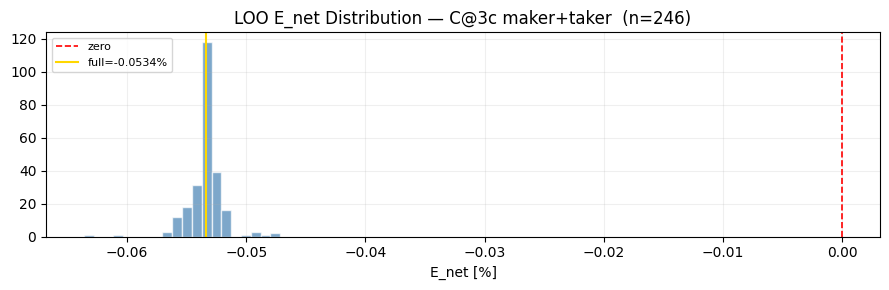

Cell 9 OK


In [8]:
# Jackknife LOO — Winner's Curse Control
print(SEP)
print(f'CELL 9 - JACKKNIFE LOO (n={len(sig_prim)})')
print(f'With n>{len(sig_prim)}, LOO is informative about distribution, not just fragility.')
print(f'Criterion: P(E_net_LOO > 0) >= {LOO_STABLE_THRESH}')
print(SEP)

ret_col    = f'cont_{PRIMARY_H}c'
fc_primary = 'fill_C_3c'

if fc_primary in sig_prim.columns:
    ra    = sig_prim[ret_col].values.astype(float)
    fa    = sig_prim[fc_primary].values.astype(bool)
    valid = ~np.isnan(ra)
    n     = len(ra)

    enet_loo = []
    for i in range(n):
        mask = np.ones(n, dtype=bool); mask[i] = False
        pf   = fa[mask].mean()
        rf   = ra[mask][fa[mask] & valid[mask]]
        if len(rf) == 0: continue
        enet_loo.append(rf.mean() * pf - NET_COST_MT)

    enet_loo  = np.array(enet_loo)
    p_loo_pos = (enet_loo > 0).mean()

    full_en   = ra[fa & valid].mean() * fa.mean() - NET_COST_MT if fa.mean() > 0 else np.nan

    print(f'\n  n={n}  |  full E_net={full_en*100:+.5f}%')
    print(f'  LOO E_net:  min={enet_loo.min()*100:+.5f}%  '
          f'p25={np.percentile(enet_loo,25)*100:+.5f}%  '
          f'median={np.median(enet_loo)*100:+.5f}%  '
          f'p75={np.percentile(enet_loo,75)*100:+.5f}%  '
          f'max={enet_loo.max()*100:+.5f}%')
    print(f'  P(LOO > 0): {p_loo_pos*100:.1f}%  (threshold: {LOO_STABLE_THRESH*100:.0f}%)')

    if p_loo_pos >= LOO_STABLE_THRESH:
        loo_verdict = f'STABLE ({p_loo_pos*100:.0f}% of LOO samples positive)'
    elif p_loo_pos >= 0.50:
        loo_verdict = f'FRAGILE ({p_loo_pos*100:.0f}%) — some events drive the edge'
    else:
        loo_verdict = f'VERY FRAGILE ({p_loo_pos*100:.0f}%) — edge not robust'

    print(f'  LOO verdict: {loo_verdict}')

    # Top influential events
    influence = full_en - enet_loo
    top_k = min(5, len(influence))
    print(f'\n  Top {top_k} influential events (if removed: largest reduction in E_net):')
    for rank, idx in enumerate(np.argsort(influence)[::-1][:top_k], 1):
        ts = sig_prim['open_time'].iloc[idx] if 'open_time' in sig_prim.columns else '?'
        print(f'  #{rank}: idx={idx}  ts={ts}  influence={influence[idx]*100:+.5f}%  '
              f'LOO_enet={enet_loo[idx]*100:+.5f}%')

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.hist(enet_loo*100, bins=min(20, len(enet_loo)), color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', ls='--', lw=1.2, label='zero')
    if not np.isnan(full_en):
        ax.axvline(full_en*100, color='gold', ls='-', lw=1.5, label=f'full={full_en*100:+.4f}%')
    ax.set_title(f'LOO E_net Distribution — C@3c maker+taker  (n={n})')
    ax.set_xlabel('E_net [%]'); ax.legend(fontsize=8); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'09b1_jackknife_loo.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('fill_C_3c not available'); p_loo_pos = np.nan; loo_verdict = 'undefined'

print('Cell 9 OK')


In [9]:
# Regime Segmentation — FQR, sign, path shape invariance
print(SEP)
print('CELL 10 - REGIME SEGMENTATION')
print('Key question: is the mechanism regime-invariant or confined to one period?')
print(f'Criterion: E_net > 0 in >= {REGIME_SIGN_THRESH}/4 regimes')
print(SEP)

ret_col    = f'cont_{PRIMARY_H}c'
fc_primary = 'fill_C_3c'

regime_paths   = {}   # avg path per regime for shape correlation
regime_summary = {}

print(f'\n  {"Regime":<22}  {"n":>4}  {"P(cont@5c)":>12}  {"FQR_C@3c":>10}  '
      f'{"P(fill,C)":>11}  {"E_net(pt)%":>12}  Sign')

n_positive = 0
for rname in REGIMES:
    mask = sig_prim['regime'] == rname
    grp  = sig_prim[mask].copy()
    n    = len(grp)

    if n < 3:
        print(f'  {rname:<22}  {n:>4}  {"--":>12}  {"--":>10}  {"--":>11}  {"--":>12}  ?')
        regime_summary[rname] = dict(n=n, pc5=np.nan, fqr=np.nan, e_net=np.nan, sign='?')
        continue

    # P(cont@5c)
    pc5 = (grp[ret_col].dropna() > 0).mean() * 100

    # FQR
    ra_g = grp[ret_col].values.astype(float)
    e_sig_g = np.nanmean(ra_g)
    fqr_g = np.nan
    e_net_g = np.nan
    p_fill_g = np.nan
    if fc_primary in grp.columns:
        fa_g  = grp[fc_primary].values.astype(bool)
        valid = ~np.isnan(ra_g)
        rf_g  = ra_g[fa_g & valid]
        p_fill_g = fa_g.mean()
        if len(rf_g) >= 2 and abs(e_sig_g) > 1e-10:
            fqr_g   = rf_g.mean() / e_sig_g
            e_net_g = rf_g.mean() * fa_g.mean() - NET_COST_MT

    sign  = ('+' if e_net_g > 0 else '-') if not np.isnan(e_net_g) else '?'
    if e_net_g is not np.nan and e_net_g > 0: n_positive += 1

    fqr_s  = f'{fqr_g:.3f}' if not np.isnan(fqr_g) else '--'
    pf_s   = f'{p_fill_g*100:.0f}%' if not np.isnan(p_fill_g) else '--'
    en_s   = f'{e_net_g*100:+.5f}%' if not np.isnan(e_net_g) else '--'
    print(f'  {rname:<22}  {n:>4}  {pc5:>11.1f}%  {fqr_s:>10}  {pf_s:>11}  {en_s:>12}  {sign}')

    # Path for this regime
    path_cols = [f'cont_{h}c' for h in range(1, PATH_H+1) if f'cont_{h}c' in grp.columns]
    regime_paths[rname]   = grp[path_cols].values.astype(float)
    regime_summary[rname] = dict(n=n, pc5=pc5, fqr=fqr_g, e_net=e_net_g, sign=sign)

print()
print(f'  Positive E_net regimes: {n_positive}/{len(REGIMES)}  (criterion: >= {REGIME_SIGN_THRESH}/4)')
if n_positive >= REGIME_SIGN_THRESH:
    print(f'  REGIME CRITERION: PASS — mechanism not confined to single period')
else:
    print(f'  REGIME CRITERION: FAIL — sign inconsistent across regimes')
print('Cell 10 OK')


CELL 10 - REGIME SEGMENTATION
Key question: is the mechanism regime-invariant or confined to one period?
Criterion: E_net > 0 in >= 3/4 regimes

  Regime                     n    P(cont@5c)    FQR_C@3c    P(fill,C)    E_net(pt)%  Sign
  2022-bear                 54         46.3%       1.802          96%     -0.05221%  -
  2023-transition           99         42.4%       0.983          93%     +0.01040%  +
  2024-bull                 68         35.3%       1.280          93%     -0.12118%  -
  2025-current              25         36.0%       3.265          92%     -0.12414%  -

  Positive E_net regimes: 1/4  (criterion: >= 3/4)
  REGIME CRITERION: FAIL — sign inconsistent across regimes
Cell 10 OK


CELL 11 - PATH SHAPE CORRELATION (h=0..10)
Key insight: if the dip→stabilization→continuation shape is geometrically similar
across regimes AND vs 09a train, the mechanism is structural, not statistical fluke.
Criterion: Pearson r >= 0.7 vs 09a train path

  09a train path (n=57): h1=-0.023%  h2=-0.046%  h3=-0.059%  h4=-0.061%  h5=-0.016%  h6=-0.032%
  Hist OOS path (n=246): h1=+0.008%  h2=+0.010%  h3=-0.006%  h4=-0.016%  h5=-0.018%  h6=-0.050%

  Subset                        n    r(vs 09a)     p-val  Shape GO?
  Historical OOS (total)      246      -0.741    0.0142  FAIL
  2022-bear                    54      -0.821    0.0036  FAIL
  2023-transition              99      +0.792    0.0063  PASS
  2024-bull                    68      -0.598    0.0678  FAIL
  2025-current                 25      -0.815    0.0041  FAIL


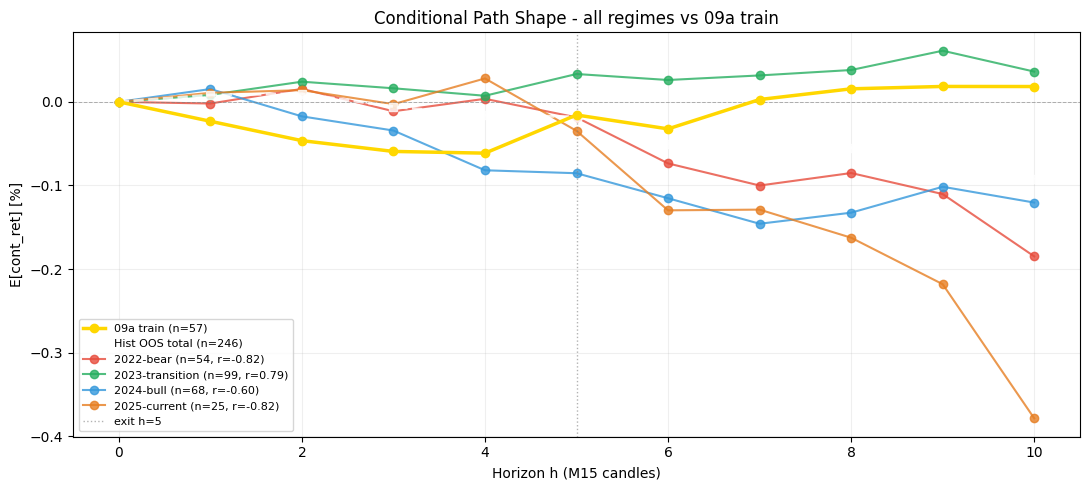

Cell 11 OK


In [10]:
# Shape Correlation — geometric invariance of the mechanism
print(SEP)
print('CELL 11 - PATH SHAPE CORRELATION (h=0..10)')
print('Key insight: if the dip→stabilization→continuation shape is geometrically similar')
print('across regimes AND vs 09a train, the mechanism is structural, not statistical fluke.')
print(f'Criterion: Pearson r >= {SHAPE_CORR_THRESH} vs 09a train path')
print(SEP)

# Build 09a train path (reference)
path_cols_all = [f'cont_{h}c' for h in range(1, PATH_H+1) if f'cont_{h}c' in sig_train09a.columns]
h_vals        = [int(c.replace('cont_','').replace('c','')) for c in path_cols_all]

if len(sig_train09a) >= 3:
    path_09a_mat  = sig_train09a[path_cols_all].values.astype(float)
    avg_09a       = np.nanmean(path_09a_mat, axis=0)
else:
    avg_09a = np.full(len(h_vals), np.nan)
    print('WARN: 09a train signals unavailable for shape reference')

print(f'\n  09a train path (n={len(sig_train09a)}): ', end='')
print('  '.join(f'h{h}={v*100:+.3f}%' for h,v in zip(h_vals[:6], avg_09a[:6])))

# Historical OOS total path
path_hist_mat = sig_prim[path_cols_all].values.astype(float)
avg_hist      = np.nanmean(path_hist_mat, axis=0)

print(f'  Hist OOS path (n={len(sig_prim)}): ', end='')
print('  '.join(f'h{h}={v*100:+.3f}%' for h,v in zip(h_vals[:6], avg_hist[:6])))

# Correlation
print(f'\n  {"Subset":<24}  {"n":>5}  {"r(vs 09a)":>11}  {"p-val":>8}  {"Shape GO?"}')
shape_results = {}

def path_corr(avg_ref, avg_test):
    valid = ~(np.isnan(avg_ref) | np.isnan(avg_test))
    if valid.sum() < 4: return np.nan, np.nan
    try:
        r, p = pearsonr(avg_ref[valid], avg_test[valid])
        return float(r), float(p)
    except Exception:
        return np.nan, np.nan

r_hist, p_hist = path_corr(avg_09a, avg_hist)
go_hist = (not np.isnan(r_hist)) and r_hist >= SHAPE_CORR_THRESH
print(f'  {"Historical OOS (total)":<24}  {len(sig_prim):>5}  {r_hist:>+10.3f}   {p_hist:>7.4f}  '
      f'{"PASS" if go_hist else "FAIL"}')
shape_results['hist_total'] = {'r': r_hist, 'p': p_hist, 'go': go_hist}

for rname, rpath_mat in regime_paths.items():
    n_r = len(rpath_mat)
    if n_r < 3:
        print(f'  {rname:<24}  {n_r:>5}  {"--":>11}  {"--":>8}  (n<3)')
        continue
    avg_r = np.nanmean(rpath_mat, axis=0)
    r_r, p_r = path_corr(avg_09a, avg_r)
    go_r = (not np.isnan(r_r)) and r_r >= SHAPE_CORR_THRESH
    print(f'  {rname:<24}  {n_r:>5}  {r_r:>+10.3f}   {p_r:>7.4f}  {"PASS" if go_r else "FAIL"}')
    shape_results[rname] = {'r': r_r, 'p': p_r, 'go': go_r}

# Plot — all regimes + 09a train overlaid
fig, ax = plt.subplots(figsize=(11, 5))
h_plot = [0] + h_vals
ax.plot([0]+h_vals, [0]+list(avg_09a*100), 'o-', lw=2.5, color='gold',  label=f'09a train (n={len(sig_train09a)})', zorder=5)
ax.plot([0]+h_vals, [0]+list(avg_hist*100), 's--', lw=2, color='white', alpha=0.8, label=f'Hist OOS total (n={len(sig_prim)})', zorder=4)

colors = ['#e74c3c', '#27ae60', '#3498db', '#e67e22']
for (rname, rpath_mat), col in zip(regime_paths.items(), colors):
    avg_r = np.nanmean(rpath_mat, axis=0)
    n_r   = len(rpath_mat)
    r_r   = shape_results.get(rname, {}).get('r', np.nan)
    ax.plot([0]+h_vals, [0]+list(avg_r*100), 'o-', lw=1.5, color=col, alpha=0.8,
            label=f'{rname} (n={n_r}, r={r_r:.2f})')

ax.axhline(0, color='gray', ls='--', lw=0.7, alpha=0.6)
ax.axvline(PRIMARY_H, color='gray', ls=':', lw=1, alpha=0.6, label=f'exit h={PRIMARY_H}')
ax.set_title('Conditional Path Shape - all regimes vs 09a train')
ax.set_xlabel('Horizon h (M15 candles)'); ax.set_ylabel('E[cont_ret] [%]')
ax.legend(fontsize=8, loc='best'); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'09b1_path_shape_regimes.png', dpi=100, bbox_inches='tight')
plt.show()
print('Cell 11 OK')


In [11]:
# Final Verdict — Structural Invariance Assessment
SEP2 = '=' * 70
print(SEP2)
print('  EXP 09b.1 - STRUCTURAL INVARIANCE — FINAL VERDICT')
print(f'  SPEC_HASH: {SPEC_HASH}')
print(f'  Historical OOS: {HIST_OOS_START.date()} to {TRAIN_09A_START.date()}')
print(f'  n_hist_oos Low+Low = {len(sig_prim)}  |  n_09b_holdout = {REF_09B["n_holdout"]}')
print(f'  n_total OOS = {len(sig_prim) + REF_09B["n_holdout"]}')
print(SEP2)

fc_primary = 'fill_C_3c'
pk = 'C@3c_maker+taker'

# ── Criteria ─────────────────────────────────────────────────────────────────
e_net_pos = enet_results.get(pk, {}).get('any_pos', False)
ci_all_go = enet_results.get(pk, {}).get('all_go', False)
loo_pass  = (not np.isnan(p_loo_pos)) and p_loo_pos >= LOO_STABLE_THRESH
shape_go  = shape_results.get('hist_total', {}).get('go', False)
fqr_c3    = fqr_results.get('C@3c', {}).get('fqr', np.nan)
fqr_ok    = (not np.isnan(fqr_c3)) and fqr_c3 >= 0.70
n_pos_regimes = sum(
    1 for rn in REGIMES
    if regime_summary.get(rn, {}).get('sign','?') == '+'
)
regime_ok = n_pos_regimes >= REGIME_SIGN_THRESH
n_core_pass = sum([e_net_pos, ci_all_go, loo_pass, shape_go, regime_ok, fqr_ok])

# ── Scorecard ─────────────────────────────────────────────────────────────────
print()
print('  ── SCORECARD ──')
print(f'  E_net[C@3c, mk+tk] > 0 (pt est):     {"PASS" if e_net_pos else "FAIL"}')
print(f'  CI_lower > 0 (all blocks):            {"PASS" if ci_all_go else "FAIL"}')
loo_pct = str(round(p_loo_pos*100,1))+'%'
print(f'  LOO stability P>={LOO_STABLE_THRESH}:           {"PASS  P="+loo_pct if loo_pass else "FAIL  P="+loo_pct}')
r_hist_str = str(round(shape_results.get("hist_total",{}).get("r",np.nan),3))
print(f'  Shape correlation r>={SHAPE_CORR_THRESH} (vs 09a): {"PASS  r="+r_hist_str if shape_go else "FAIL  r="+r_hist_str}')
print(f'  Regime sign >=3/4 positive:           {"PASS  "+str(n_pos_regimes)+"/4" if regime_ok else "FAIL  "+str(n_pos_regimes)+"/4"}')
fqr_str = str(round(fqr_c3, 3)) if not np.isnan(fqr_c3) else 'nan'
print(f'  FQR_C@3c >= 0.70:                     {"PASS  FQR="+fqr_str if fqr_ok else "FAIL  FQR="+fqr_str}')
print(f'  Total: {n_core_pass}/6 criteria pass')

# ── Bear > Bull liquidity stress detector ─────────────────────────────────────
print()
print('  ── REGIME MECHANISM SIGNAL ──')
bear_enet = regime_summary.get('2022-bear', {}).get('e_net', np.nan)
bull_enet = regime_summary.get('2024-bull', {}).get('e_net', np.nan)
bear_pc5  = regime_summary.get('2022-bear', {}).get('pc5',  np.nan)
bull_pc5  = regime_summary.get('2024-bull', {}).get('pc5',  np.nan)

if not (np.isnan(bear_enet) or np.isnan(bull_enet)):
    bear_stronger = bear_enet > bull_enet
    bear_str = f'{bear_enet*100:+.5f}%'
    bull_str = f'{bull_enet*100:+.5f}%'
    print(f'  E_net: bear={bear_str}  |  bull={bull_str}')
    if not (np.isnan(bear_pc5) or np.isnan(bull_pc5)):
        print(f'  P(cont@5c): bear={bear_pc5:.1f}%  |  bull={bull_pc5:.1f}%')
    if bear_stronger:
        print()
        print('  *** LIQUIDITY STRESS PATTERN DETECTED ***')
        print('  Bear regime shows stronger continuation than bull regime.')
        print('  Interpretation: mechanism is NOT classic momentum.')
        print('  Driver is consistent with: liquidity stress, forced positioning,')
        print('  inventory transfer under directional pressure — NOT trend-following.')
        print('  Future path implication: OI/funding/liquidation data would')
        print('  allow direct causal test of this hypothesis.')
    else:
        print()
        print('  Bear <= Bull continuation: no liquidity stress signal.')
        print('  Mechanism may be momentum-driven or regime-agnostic.')
else:
    print('  Insufficient data to compare bear vs bull E_net.')
    print('  (check n_regime in Cell 10 output)')

# ── Three-outcome classification ──────────────────────────────────────────────
print()
print('  ── OUTCOME CLASSIFICATION ──')

# Determine FQR regime consistency (how many regimes have FQR available)
fqr_regime_vals = [
    regime_summary.get(rn, {}).get('fqr', np.nan) for rn in REGIMES
]
n_fqr_stable = sum(1 for v in fqr_regime_vals if not np.isnan(v) and v >= 0.70)

# Path geometry consistent = shape_go on hist_total + most regime shapes pass
n_shape_pass = sum(
    1 for rn in REGIMES
    if shape_results.get(rn, {}).get('go', False)
)

full_structural = (
    e_net_pos and ci_all_go and loo_pass and shape_go and regime_ok and fqr_ok
)
regime_dependent = (
    e_net_pos and loo_pass
    and (not regime_ok)          # some regimes fail sign
    and n_pos_regimes >= 2       # but at least 2 are positive
    and (shape_go or n_shape_pass >= 2)
)
collapse = not e_net_pos and not shape_go

if full_structural:
    category = 'FULL STRUCTURAL PASS'
    cat_lines = [
        'Path geometry, FQR, sign consistency, and E_net are all robust across regimes.',
        'Causally coherent, temporally stable, not explained by overfitting.',
        'First truly structural result in this series.',
    ]
    verdict_next = [
        'FROZEN. Do not touch thresholds, quantiles, or horizons.',
        'Next: Exp10 — Paper trading (min 50 live signals before any capital commitment)',
        'Track: live fill rate vs Model C, actual slippage, rebate realization rate',
        'Parallel: Exp09b.2 with ETH/USDT M15 — out-of-instrument structural check',
    ]
elif regime_dependent:
    category = 'REGIME-DEPENDENT EFFECT'
    pos_names = [rn for rn in REGIMES if regime_summary.get(rn,{}).get('sign','?')=='+']
    cat_lines = [
        'Effect holds in ' + str(n_pos_regimes) + '/4 regimes: ' + ', '.join(pos_names) + '.',
        'Mechanism is NOT universal but is NOT noise either.',
        'A regime-conditional causal variable has been identified.',
        'Driver likely depends on inventory conditions or regime-specific liquidity state.',
    ]
    verdict_next = [
        'Do NOT recalibrate. Understand WHICH regimes activate the mechanism.',
        'Investigate: funding rates, OI spikes, or liquidation volume in active regimes?',
        'Path: Exp09b.2 (ETH M15) — same regime dependency cross-asset?',
        'Longer term: regime classifier as a filter before signal entry.',
    ]
elif collapse:
    category = 'COLLAPSE UNDER BACKWARD TRANSFER'
    cat_lines = [
        'Path shape disappears, FQR falls, sign inconsistent across regimes.',
        'Exp09a result was likely sample luck + low-n amplification.',
        'Methodologically clean: frozen thresholds made the test falsifiable.',
        'The negative result is as informative as a positive one.',
    ]
    verdict_next = [
        'CRITICAL: Do NOT adjust thresholds, quantiles, or horizons post-hoc.',
        'Do NOT rerun with different parameters — that negates the OOS integrity.',
        'Bounded Claim CLOSED: {OHLCV, M1+M15, EER=Low+Low} -> directional alpha ~= 0',
        'Path A: L2 book microstructure — requires new data infrastructure',
        'Path B: H1/H4 native hypotheses — same pipeline, no new data needed',
        'Path C: OI/liquidation mechanics — requires funding/OI data integration',
    ]
else:
    category = 'MIXED (' + str(n_core_pass) + '/6 criteria pass)'
    cat_lines = [
        'Neither full structural pass nor full collapse. Intermediate evidence.',
        'Review regime segmentation and shape correlation for root cause.',
    ]
    verdict_next = [
        'Do NOT recalibrate. Identify which specific criteria fail and why.',
        'shape_go=False but e_net_pos=True: likely noise with weak geometric structure',
        'shape_go=True but ci_all_go=False: data still underpowered, need more events',
        'regime_ok=False: regime-dependent effect, see REGIME-DEPENDENT path above',
    ]

print('  OUTCOME: ' + category)
for ln in cat_lines:
    print('    ' + ln)
print()
print('  Next steps:')
for s in verdict_next:
    print(f'    - {s}')

# ── Bounded claim status ───────────────────────────────────────────────────────
print()
print('  ── BOUNDED CLAIM STATUS (post 09b.1) ──')
print('  Closed: {OHLCV, M1, all signal families, retail taker+maker} -> alpha ~= 0')
if full_structural:
    print('  STRUCTURAL CANDIDATE: {OHLCV, M15, EER=Low+Vol=Low, maker, h=5}')
    print('    -> E_net > 0, CI_lower > 0, LOO stable, shape invariant 2022-2026')
    print('    -> Pending: live paper trading validation (Exp10)')
elif regime_dependent:
    print('  CONDITIONAL CANDIDATE: {OHLCV, M15, EER=Low+Vol=Low, maker, h=5 | regime in '+str([rn for rn in REGIMES if regime_summary.get(rn,{}).get("sign","?")=="+"])+'}')
    print('    -> E_net > 0 in active regimes, LOO stable, but full universality not confirmed')
elif e_net_pos:
    print(f'  CANDIDATE (unresolved): E_net > 0, but {6-n_core_pass} criteria still failing')
else:
    print('  Closed: {OHLCV, M15, EER=Low+Vol=Low} -> alpha ~= 0 (historical OOS failed)')
    print('  Open: {H1/H4 OHLCV}  {L2 book}  {OI/liquidation mechanics}')

print()
print(SEP2)
print('Cell 12 OK — Exp09b.1 complete')


  EXP 09b.1 - STRUCTURAL INVARIANCE — FINAL VERDICT
  SPEC_HASH: 15610181a8cd
  Historical OOS: 2022-01-01 to 2025-05-29
  n_hist_oos Low+Low = 246  |  n_09b_holdout = 12
  n_total OOS = 258

  ── SCORECARD ──
  E_net[C@3c, mk+tk] > 0 (pt est):     FAIL
  CI_lower > 0 (all blocks):            FAIL
  LOO stability P>=0.7:           FAIL  P=0.0%
  Shape correlation r>=0.7 (vs 09a): FAIL  r=-0.741
  Regime sign >=3/4 positive:           FAIL  1/4
  FQR_C@3c >= 0.70:                     PASS  FQR=2.007
  Total: 1/6 criteria pass

  ── REGIME MECHANISM SIGNAL ──
  E_net: bear=-0.05221%  |  bull=-0.12118%
  P(cont@5c): bear=46.3%  |  bull=35.3%

  *** LIQUIDITY STRESS PATTERN DETECTED ***
  Bear regime shows stronger continuation than bull regime.
  Interpretation: mechanism is NOT classic momentum.
  Driver is consistent with: liquidity stress, forced positioning,
  inventory transfer under directional pressure — NOT trend-following.
  Future path implication: OI/funding/liquidation data wo